In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/gaura/Downloads/Datasets.csv")

df = df[[
    "step", "type", "amount",
    "nameOrig", "nameDest",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "isFraud"
]]

df = df.dropna()

print("Data Loaded ✅")

Data Loaded ✅


In [2]:
# Save cleaned dataset
output_path = "C:/Users/gaura/Downloads/cleaned_fraud_data.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved at:", output_path)

Cleaned dataset saved at: C:/Users/gaura/Downloads/cleaned_fraud_data.csv


In [3]:
# Amount anomaly (relative to balance)
df["amount_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)

# Round number bias
df["round_amount"] = (df["amount"] % 1000 == 0).astype(int)

# Balance mismatch (very powerful)
df["balance_error"] = abs(
    (df["oldbalanceOrg"] - df["newbalanceOrig"]) - df["amount"]
)

In [4]:
# Transaction frequency per user
df["transaction_count"] = df.groupby("nameOrig")["amount"].transform("count")

# Average transaction per user
df["avg_amount_user"] = df.groupby("nameOrig")["amount"].transform("mean")

# Deviation from user behavior
df["amount_deviation"] = abs(df["amount"] - df["avg_amount_user"])

# First-time destination
df["is_new_dest"] = (~df["nameDest"].isin(df["nameDest"].value_counts().index[:100])).astype(int)

In [5]:
# Time bucket (simulate day/night)
df["time_bucket"] = (df["step"] % 24)

# Odd hour transaction
df["odd_time"] = ((df["time_bucket"] < 6) | (df["time_bucket"] > 22)).astype(int)

In [6]:
# Sort for sequence
df = df.sort_values(by=["nameOrig", "step"])

# Time gap between transactions
df["time_gap"] = df.groupby("nameOrig")["step"].diff().fillna(0)

# Velocity (inverse gap)
df["velocity"] = 1 / (df["time_gap"] + 1)

In [7]:
# Count transactions per destination
df["dest_count"] = df.groupby("nameDest")["amount"].transform("count")

# Sudden vendor appearance
df["new_vendor_risk"] = (df["dest_count"] < 5).astype(int)

In [8]:
df["first_digit"] = df["amount"].astype(str).str[0].astype(int)

benford_dist = df["first_digit"].value_counts(normalize=True)

# simple deviation flag (approximation)
df["benford_flag"] = df["first_digit"].isin([7, 8, 9]).astype(int)

In [9]:
df["is_duplicate"] = df.duplicated(
    subset=["amount", "nameDest", "step"], keep=False
).astype(int)

In [10]:
df["threshold_flag"] = ((df["amount"] > 4900) & (df["amount"] < 5000)).astype(int)

In [11]:
df["prev_amount"] = df.groupby("nameOrig")["amount"].shift(1).fillna(0)

df["sudden_spike"] = ((df["amount"] > 3 * df["prev_amount"])).astype(int)

In [12]:
df["rapid_txn_flag"] = (df["time_gap"] < 2).astype(int)

In [13]:
df["self_transfer"] = (df["nameOrig"] == df["nameDest"]).astype(int)

In [14]:
from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

df["name_similarity"] = df.apply(
    lambda x: similarity(x["nameOrig"], x["nameDest"]), axis=1
)


df["fuzzy_flag"] = (df["name_similarity"] > 0.8).astype(int)

In [15]:
df["unique_receivers"] = df.groupby("nameOrig")["nameDest"].transform("nunique")

df["multi_receiver_flag"] = (df["unique_receivers"] > 5).astype(int)

In [16]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

In [17]:
print(df.head())
print(df.shape)

      step      amount     nameOrig     nameDest  oldbalanceOrg  \
2332     1     2655.04    C10001825  C1850180796       21214.00   
8956     7     1980.51   C100033245   M945195126         388.00   
4995     5    67017.13  C1000600589  C1163619825     3942544.19   
6117     6  1280020.98  C1000719581  C1262822392           0.00   
9481     7     7860.26  C1001830827   M838403351           0.00   

      newbalanceOrig  oldbalanceDest  newbalanceDest  isFraud  amount_ratio  \
2332        18558.96      1116396.05      1268668.92      0.0  1.251492e-01   
8956            0.00            0.00            0.00      0.0  5.091285e+00   
4995      4009561.32       118844.67        51827.53      0.0  1.699844e-02   
6117            0.00     13500000.00     16900000.00      0.0  1.280021e+06   
9481            0.00            0.00            0.00      0.0  7.860260e+03   

      ...  rapid_txn_flag  self_transfer  name_similarity  fuzzy_flag  \
2332  ...               1              0         

In [18]:
df.to_csv("C:/Users/gaura/Downloads/featured_fraud_data.csv", index=False)
print("Feature dataset saved ✅")

Feature dataset saved ✅


In [19]:
features = [
    "amount",
    "amount_ratio",
    "balance_error",
    "amount_deviation",
    "velocity",
    "odd_time",
    "new_vendor_risk",
    "fuzzy_flag",
    "multi_receiver_flag"
] + [col for col in df.columns if "type_" in col]

In [20]:
df_safe = df[df["isFraud"] == 0]
df_fraud = df[df["isFraud"] == 1]

df_safe_sample = df_safe.sample(n=len(df_fraud)*2, random_state=42)

df_small = pd.concat([df_safe_sample, df_fraud]).sample(frac=1)

In [21]:
X = df_small[features]
y = df_small["isFraud"]

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y_resampled).value_counts())

After SMOTE:
0.0    136
1.0    136
Name: isFraud, dtype: int64


In [22]:
X = X_resampled
y = y_resampled

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_resampled, y_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9454545454545454


In [25]:
def predict_transaction(input_data):
    input_df = pd.DataFrame([input_data])[X.columns]
    prob = model.predict_proba(input_df)[0][1]

    # Base risk from ML
    risk = prob * 100
    reasons = []

    # 🔥 Rule Engine (clean & scalable)
    rules = [
        {
            "condition": input_data["amount"] > 50000,
            "impact": 10,
            "reason": "High transaction amount"
        },
        {
            "condition": input_data["velocity"] > 0.5,
            "impact": 10,
            "reason": "High velocity"
        },
        {
            "condition": input_data["odd_time"] == 1,
            "impact": 5,
            "reason": "Unusual timing"
        },
        {
            "condition": input_data["fuzzy_flag"] == 1,
            "impact": 15,
            "reason": "Fuzzy entity match"
        },
        {
            "condition": input_data["multi_receiver_flag"] == 1,
            "impact": 10,
            "reason": "Multiple receivers pattern"
        }
    ]

    # Apply rules
    for rule in rules:
        if rule["condition"]:
            risk += rule["impact"]
            reasons.append(rule["reason"])

    # Cap risk
    risk = min(risk, 100)

    # 🎯 Decision Layer (clean thresholds)
    if risk >= 70:
        decision, action = "⚠️ Fraud", "Block"
    elif risk >= 50:
        decision, action = "⚠️ Suspicious", "Verify"
    else:
        decision, action = "✅ Safe", "Allow"

    return {
        "decision": decision,
        "risk_score": risk,
        "reasons": reasons,
        "action": action
    }

In [26]:
# Try multiple fraud cases
for i in range(5):
    sample = X[y == 1].iloc[i].to_dict()
    print(predict_transaction(sample))

{'decision': '⚠️ Fraud', 'risk_score': 90.94958377957371, 'reasons': ['High velocity'], 'action': 'Block'}
{'decision': '⚠️ Fraud', 'risk_score': 92.28816536196996, 'reasons': ['High velocity'], 'action': 'Block'}
{'decision': '⚠️ Fraud', 'risk_score': 97.59683848880557, 'reasons': ['High velocity', 'Unusual timing'], 'action': 'Block'}
{'decision': '⚠️ Fraud', 'risk_score': 100, 'reasons': ['High transaction amount', 'High velocity', 'Unusual timing'], 'action': 'Block'}
{'decision': '⚠️ Fraud', 'risk_score': 94.32256209780209, 'reasons': ['High velocity'], 'action': 'Block'}


In [27]:
print(pd.Series(y_resampled).value_counts())

0.0    136
1.0    136
Name: isFraud, dtype: int64


In [28]:
print(pd.Series(y_resampled).value_counts(normalize=True) * 100)

0.0    50.0
1.0    50.0
Name: isFraud, dtype: float64


In [29]:
import joblib
joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

In [30]:
import json

with open("features.json", "w") as f:
    json.dump(features, f)

In [31]:
import pandas as pd

df = pd.read_csv("C:/Users/gaura/Downloads/featured_fraud_data.csv")

In [32]:
# Convert to DataFrame
df_smote = pd.DataFrame(X_resampled, columns=features)

# Add target column back
df_smote["isFraud"] = y_resampled

# Save to CSV
df_smote.to_csv("C:/Users/gaura/Downloads/smote_balanced_data.csv", index=False)

print("SMOTE dataset saved ✅")

SMOTE dataset saved ✅


In [33]:
print(df_small["isFraud"].value_counts())

0.0    136
1.0     68
Name: isFraud, dtype: int64


In [34]:
import numpy, pandas, sklearn, shap

print(numpy.__version__)   # 1.26.x
print("All working ✅")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


1.26.4
All working ✅


In [35]:
import numpy as np

def monte_carlo_simulation(
    initial_balance=100000,
    months=12,
    simulations=1000,
    avg_cashflow=5000,
    std_cashflow=20000
):
    results = []

    for _ in range(simulations):
        balance = initial_balance

        for _ in range(months):
            cashflow = np.random.normal(avg_cashflow, std_cashflow)
            balance += cashflow

        results.append(balance)

    results = np.array(results)

    survival_rate = (results > 0).mean() * 100

    return results, survival_rate

In [36]:
results, survival_rate = monte_carlo_simulation()

print(f"Survival Probability: {survival_rate:.2f}%")

Survival Probability: 98.90%


In [37]:
import matplotlib.pyplot as plt

def plot_results(results):
    plt.hist(results, bins=50, color='skyblue')

    plt.axvline(0, color='red', linestyle='--', label='Failure Threshold')

    plt.title("Monte Carlo Simulation - Cash Flow Outcomes")
    plt.xlabel("Final Balance")
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

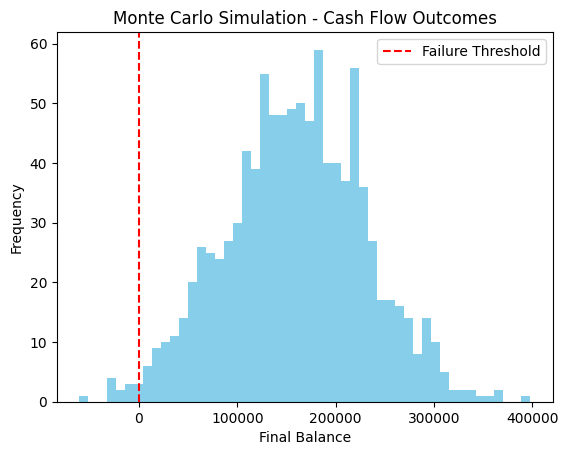

In [38]:
plot_results(results)

In [39]:
def survival_category(rate):
    if rate > 80:
        return "🟢 Safe"
    elif rate > 50:
        return "🟡 Moderate Risk"
    else:
        return "🔴 Critical"

In [40]:
print(survival_category(survival_rate))

🟢 Safe


In [41]:
fraud_rate = df["isFraud"].mean() * 100
print("Fraud Rate:", fraud_rate)

Fraud Rate: 0.6728676034039185


In [42]:
import numpy as np

industry_samples = np.random.normal(loc=1.5, scale=0.5, size=1000)

In [43]:
industry_mean = industry_samples.mean()

print("Industry Avg:", industry_mean)

Industry Avg: 1.5065901395470918


In [44]:
def benchmark_category(company_rate, industry_mean):
    if company_rate < industry_mean:
        return "🟢 Better than Industry"
    elif company_rate < industry_mean * 1.5:
        return "🟡 Slightly Risky"
    else:
        return "🔴 High Risk (Above Industry)"

In [45]:
status = benchmark_category(fraud_rate, industry_mean)
print("Benchmark Status:", status)

Benchmark Status: 🟢 Better than Industry


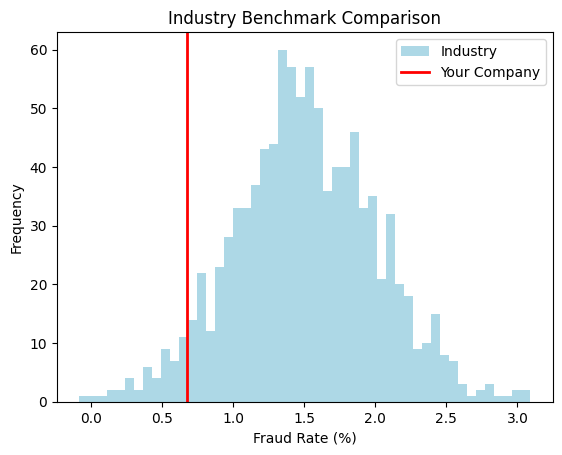

In [46]:
import matplotlib.pyplot as plt

plt.hist(industry_samples, bins=50, color='lightblue', label='Industry')

plt.axvline(fraud_rate, color='red', linewidth=2, label='Your Company')

plt.title("Industry Benchmark Comparison")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [49]:
input_data = {
    "amount": 70000,
    "amount_ratio": 2.5,
    "balance_error": 1000,
    "amount_deviation": 20000,
    "velocity": 0.8,
    "odd_time": 1,
    "new_vendor_risk": 1,
    "fuzzy_flag": 0,
    "multi_receiver_flag": 1,

    # type encoding (IMPORTANT)
    "type_TRANSFER": 1,
    "type_CASH_OUT": 0,
    "type_PAYMENT": 0,
    "type_DEBIT": 0
}

result = predict_transaction(input_data)

fraud_risk = result["risk_score"]

# simulate impact
fraud_rate = fraud_risk / 100 * 5   # scaled estimate

status = benchmark_category(fraud_rate, industry_mean)